# IMEN266 · Ch.5 · Class Problems 7 — Modeling a system as a CTMC

**How this notebook works** — every problem follows the same 5 steps:

> **Problem → Model → Analytic → Simulate & Visualize → Experiment**

The analytic answer and the simulation must agree. *That agreement — not the
instructor, not an AI — is your ground truth.*

**In-class version only:** cells marked `# TODO` are for you to complete during
class. A `check(...)` cell right after tells you immediately whether your answer
matches the reference value.

▶ Open in Colab: `https://colab.research.google.com/github/youngmko/imen266-2026/blob/main/ch05/notebooks/CP7_ctmc_modeling.ipynb`

**The recipe of this notebook** *(slides pp. 16–18/63; Companion §1.3, Proof 4)*

1. Define $X(t)$, the state at time $t$; 2. write down the state space $S$;
3. verify the Markov property (exponential clocks, one per possible transition);
4. write the **generator** $Q=[q_{ij}]$: $q_{ij}$ = rate of the clock $i\to j$,
   $q_{ii}=-\sum_{j\ne i}q_{ij}$ (rows sum to 0); 5. draw the **rate diagram**.

In code: `CTMC(Q, states)` checks the row sums; `chain.rates` gives $\lambda_i=-q_{ii}$;
`chain.embedded_chain()` gives the jump chain; `chain.sample_path(T, x0, rng)` simulates
with competing exponential clocks; `empirical_Q(chain, t, x)` estimates $Q$ back from a path.

In [1]:
# --- IMEN266 setup (Ch.5): course package + helpers ---------------------------
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.linalg import expm

try:                                   # local clone / PLMS zip: package is on the path
    from imen266.ctmc import CTMC
except ImportError:                    # Colab: fetch the course package from GitHub (~5 s)
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/youngmko/imen266-2026.git"], check=True)
    from imen266.ctmc import CTMC
from imen266.ctmc import (birth_death, bd_stationary, machine_repair, erlang_loss,
                          expm_series, expm_limit, poisson_process, thin, merge)
from imen266.dtmc import DTMC
from imen266.check import check        # [TODO]/[OK]/[X] self-check (unfinished TODOs never crash)

rng = np.random.default_rng(2026)
plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11,
                     "legend.frameon": False})

def build_ctmc(Q, states=None):
    """CTMC(Q) if Q is complete and valid; otherwise None (keeps 'Run all' alive)."""
    Q = np.asarray(Q, dtype=float)
    if np.isnan(Q).any():
        print("[TODO] Q still contains NaN entries - finish the TODO above."); return None
    try:
        return CTMC(Q, states)
    except ValueError as e:
        print("[X  ] Q is not a valid generator:", e); return None

def check_rows0(Q):
    """Every row of a generator sums to 0; off-diagonal entries are >= 0."""
    Q = np.asarray(Q, dtype=float)
    if np.isnan(Q).any():
        return check("rows sum to 0, off-diagonal >= 0", None, 0.0, tol=1e-9)
    off = Q - np.diag(np.diag(Q))
    err = float(np.abs(Q.sum(axis=1)).max() + (off < 0).sum())
    return check("rows sum to 0, off-diagonal >= 0", err, 0.0, tol=1e-9)

def empirical_Q(chain, t, x):
    """Estimate the generator from a sample path: (# jumps i->j) / (time spent in i)."""
    n = chain.n; Qh = np.zeros((n, n)); T = np.zeros(n)
    for k in range(len(x) - 1):
        T[x[k]] += t[k + 1] - t[k]
        if x[k + 1] != x[k]: Qh[x[k], x[k + 1]] += 1
    with np.errstate(divide="ignore", invalid="ignore"):
        Qh = np.where(T[:, None] > 0, Qh / T[:, None], 0.0)
    np.fill_diagonal(Qh, -Qh.sum(axis=1))
    return Qh

def plot_path(t, x, states=None, ax=None, title=None, **kw):
    """Step plot of a CTMC sample path (t, x) as returned by chain.sample_path."""
    ax = ax or plt.gca()
    ax.step(t, x, where="post", **kw)
    if states is not None:
        ax.set_yticks(range(len(states))); ax.set_yticklabels([str(s) for s in states])
    ax.set_xlabel("t"); ax.set_ylabel("state")
    if title: ax.set_title(title)
    return ax

try:
    from ipywidgets import interact, FloatSlider, IntSlider, FloatLogSlider
    HAS_W = True
except Exception:
    HAS_W = False

def show(fn, **sliders):
    """interact() if widgets are available; otherwise draw once with defaults."""
    if HAS_W:
        interact(fn, **sliders)
    else:
        fn(**{k: getattr(v, "value", v) for k, v in sliders.items()})

print("Setup OK.  CTMC imported.  Widgets available:", HAS_W)

Setup OK.  CTMC imported.  Widgets available: True


---
## Warm-up · Competing clocks *are* the generator *(slides pp. 17–18, 34/63)*

In state $i$ start one $\exp(q_{ij})$ clock per possible transition. Two facts
(Companion Proof 1 / slide 34/63) make this a CTMC: the **time in $i$** is
$\min_j$ of the clocks $\sim\exp(\lambda_i)$ with $\lambda_i=\sum_{j\ne i}q_{ij}$, and
**clock $j$ wins** with probability $q_{ij}/\lambda_i$ — independently of *when* it wins.

sojourn mean: 0.0997   1/sum(q) = 0.1
winner freq : [0.200805 0.29769  0.501505]   q/sum(q) = [0.2 0.3 0.5]
winner freq | short sojourn: [0.201 0.297 0.502]
winner freq | long sojourn : [0.201 0.298 0.501]


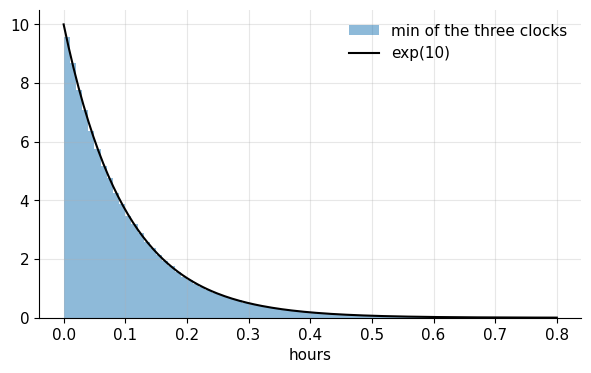

In [2]:
q = np.array([2.0, 3.0, 5.0])                     # three clocks out of state i (rates per hour)
n = 200_000
clocks = rng.exponential(1/q, (n, 3))              # one row = one visit to state i
sojourn, winner = clocks.min(axis=1), clocks.argmin(axis=1)
print("sojourn mean:", sojourn.mean().round(4), "  1/sum(q) =", (1/q.sum()).round(4))
print("winner freq :", np.bincount(winner)/n, "  q/sum(q) =", (q/q.sum()).round(4))
# independence of 'who' and 'when': the winner frequencies among SHORT and LONG sojourns agree
short, long_ = sojourn < np.median(sojourn), sojourn >= np.median(sojourn)
print("winner freq | short sojourn:", (np.bincount(winner[short], minlength=3)/short.sum()).round(3))
print("winner freq | long sojourn :", (np.bincount(winner[long_], minlength=3)/long_.sum()).round(3))
plt.figure(); plt.hist(sojourn, bins=80, range=(0, .8), density=True, alpha=.5, label="min of the three clocks")
tt = np.linspace(0, .8, 200); plt.plot(tt, q.sum()*np.exp(-q.sum()*tt), "k", label=f"exp({q.sum():.0f})"); plt.legend(); plt.xlabel("hours"); plt.show()

**Think about it** — Suppose the clocks were *deterministic* (2 h, 3 h, 5 h
until each event). Which clock would always win, and why can such a system never
be a CTMC in the states-and-rates sense?

---
## Problem 1 — One machine, up and down *(slides pp. 19–20/63)*

> Consider a machine that operates for an $\exp(\mu)$ amount of time and then fails.
> Once it fails, it gets repaired. The repair time is an $\exp(\lambda)$ random variable,
> independent of the past. The machine is as good as new after the repair. Let $X(t)$
> be the state of the machine at time $t$, 1 if it is up and 0 if it is down. Model
> this as a CTMC.

### Model
$S=\{0,1\}$. Up$\to$down at rate $\mu$ (the up-time clock), down$\to$up at rate
$\lambda$ (the repair clock):
$$Q=\begin{pmatrix}-\lambda&\lambda\\ \mu&-\mu\end{pmatrix}\qquad(\text{rows: }0,1).$$
No self-loops in the rate diagram; the diagonal only records the total rate of leaving.

In [3]:
lam, mu = 2.0, 0.1                  # repair rate (per day), failure rate (per day): mean repair 12 h, mean up time 10 days
Q1 = np.array([[-lam, lam],
               [ mu, -mu]])
machine = build_ctmc(Q1, ["down", "up"])
print(machine.summary())
print("mean sojourn times (days):", machine.mean_sojourn().round(3), "   embedded P:\n", machine.embedded_chain().P)

2 states; 1 communicating class(es)
  ['down', 'up']: recurrent
absorbing: none
sojourn rates lambda_i: [2.0, 0.1]
irreducible (finite => ergodic, no aperiodicity needed): True
mean sojourn times (days): [ 0.5 10. ]    embedded P:
 [[0. 1.]
 [1. 0.]]


In [4]:
check_rows0(Q1)
check("q[down,up] = lambda", None if np.isnan(Q1[0, 1]) else Q1[0, 1], lam, tol=1e-9)
check("q[up,down] = mu",    None if np.isnan(Q1[1, 0]) else Q1[1, 0], mu,  tol=1e-9)

[OK ] rows sum to 0, off-diagonal >= 0: got 0   (reference 0)
[OK ] q[down,up] = lambda: got 2   (reference 2)
[OK ] q[up,down] = mu: got 0.1   (reference 0.1)


True

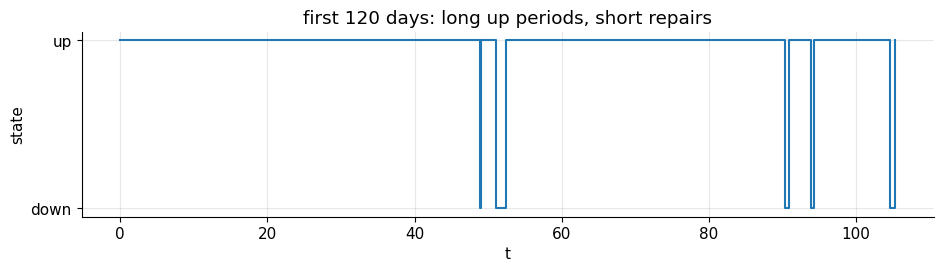

empirical Q from the path:
 [[-2.06   2.06 ]
 [ 0.101 -0.101]] 
(true Q)
 [[-2.   2. ]
 [ 0.1 -0.1]]
fraction of time up (sim): 0.9535    (Ch.5 Part 3 will give lambda/(lambda+mu) = 0.9524 )


In [5]:
# --- Simulate 2 years with competing clocks; estimate Q back from the path ------------------
if machine:
    t, x = machine.sample_path(730, x0="up", rng=rng)
    fig, ax = plt.subplots(figsize=(11, 2.4)); plot_path(t[t < 120], x[:np.sum(t < 120)], machine.states, ax, "first 120 days: long up periods, short repairs")
    plt.show()
    print("empirical Q from the path:\n", empirical_Q(machine, t, x).round(3), "\n(true Q)\n", Q1)
    print("fraction of time up (sim):", machine.occupancy((t, x))[1].round(4), "   (Ch.5 Part 3 will give lambda/(lambda+mu) =", round(lam/(lam+mu), 4), ")")

**Think about it** — (i) `empirical_Q` divides *jump counts* by *time spent* —
why is that the right estimator of a rate? (ii) The embedded chain of this CTMC is
$\begin{pmatrix}0&1\\1&0\end{pmatrix}$ whatever $\lambda,\mu$: the jump chain forgets
the speeds. What does it remember?

---
## Problem 2 — Two photocopy machines, two repair persons *(slides pp. 21–22/63)*

> There are two identical photocopy machines in our department. The up times of each
> machine are exponentially distributed with mean 2.5 days [...] The down times of each
> machine are exponentially distributed with mean 0.5 day. It is possible that both
> machines are down and we have 2 repair persons [...] Let $X(t)$ be the number of
> machines that are up at time $t$. Model $\{X(t),t\ge0\}$ as a CTMC.

### Model
$S=\{0,1,2\}$, failure rate $\lambda=1/2.5=0.4$ per day, repair rate $\mu=1/0.5=2$ per day.
With two machines up, **two** independent failure clocks run: $2\to1$ at rate $2\lambda$.
With two down and two repair persons: $0\to1$ at rate $2\mu$. Two clocks never ring at the
same instant, so there is no $2\to0$ arc:
$$Q=\begin{pmatrix}-4&4&0\\0.4&-2.4&2\\0&0.8&-0.8\end{pmatrix}.$$

In [6]:
lam, mu = 1/2.5, 1/0.5
Q2 = np.array([[-2*mu, 2*mu, 0],
               [lam, -(lam+mu), mu],
               [0, 2*lam, -2*lam]])
photocopy = build_ctmc(Q2, [0, 1, 2])
print(Q2); print(photocopy.summary())
print("same thing from the course helper machine_repair(2 machines, 2 crews):\n", machine_repair(2, 2, lam, mu).Q)

[[-4.   4.   0. ]
 [ 0.4 -2.4  2. ]
 [ 0.   0.8 -0.8]]
3 states; 1 communicating class(es)
  [0, 1, 2]: recurrent
absorbing: none
sojourn rates lambda_i: [4.0, 2.4, 0.8]
irreducible (finite => ergodic, no aperiodicity needed): True
same thing from the course helper machine_repair(2 machines, 2 crews):
 [[-4.   4.   0. ]
 [ 0.4 -2.4  2. ]
 [ 0.   0.8 -0.8]]


In [7]:
check_rows0(Q2)
_ref = machine_repair(2, 2, lam, mu).Q
check("q[0,1] = 2 mu",     None if np.isnan(Q2[0, 1]) else Q2[0, 1], _ref[0, 1], tol=1e-9)
check("q[1,0] = lambda",   None if np.isnan(Q2[1, 0]) else Q2[1, 0], _ref[1, 0], tol=1e-9)
check("q[1,2] = mu",       None if np.isnan(Q2[1, 2]) else Q2[1, 2], _ref[1, 2], tol=1e-9)
check("q[2,1] = 2 lambda", None if np.isnan(Q2[2, 1]) else Q2[2, 1], _ref[2, 1], tol=1e-9)
check("q[2,0] = 0",        None if np.isnan(Q2[2, 0]) else Q2[2, 0], 0.0, tol=1e-9)

[OK ] rows sum to 0, off-diagonal >= 0: got 0   (reference 0)
[OK ] q[0,1] = 2 mu: got 4   (reference 4)
[OK ] q[1,0] = lambda: got 0.4   (reference 0.4)
[OK ] q[1,2] = mu: got 2   (reference 2)
[OK ] q[2,1] = 2 lambda: got 0.8   (reference 0.8)
[OK ] q[2,0] = 0: got 0   (reference 0)


True

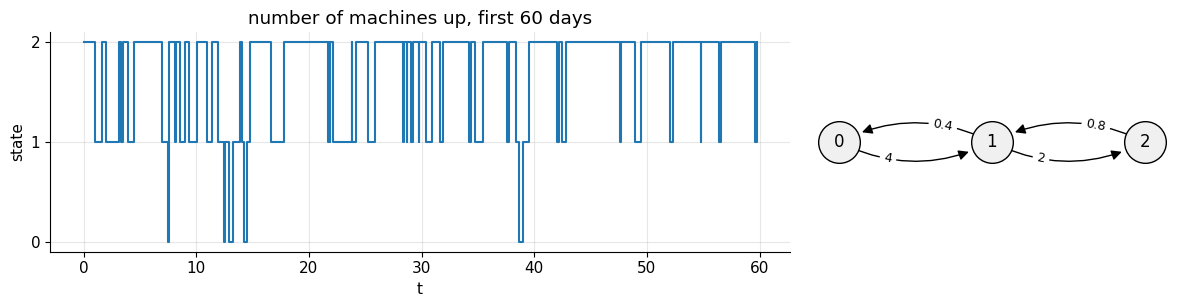

empirical Q:
 [[-4.03  4.03  0.  ]
 [ 0.44 -2.43  1.99]
 [ 0.    0.73 -0.73]]
time fractions (sim): [0.028 0.26  0.712]   <- CP8 #2 derives (1, 10, 25)/36 = [0.028 0.278 0.694]


In [8]:
# --- Simulate 3 years and recover the rates; draw the rate diagram -------------------------
if photocopy:
    t, x = photocopy.sample_path(3*365, x0=2, rng=rng)
    fig, ax = plt.subplots(1, 2, figsize=(12, 3.2), gridspec_kw={"width_ratios": [2, 1]})
    plot_path(t[t < 60], x[:np.sum(t < 60)], photocopy.states, ax[0], "number of machines up, first 60 days")
    photocopy.plot_rate_diagram(ax=ax[1], layout="line"); plt.tight_layout(); plt.show()
    print("empirical Q:\n", empirical_Q(photocopy, t, x).round(2))
    print("time fractions (sim):", photocopy.occupancy((t, x)).round(3), "  <- CP8 #2 derives (1, 10, 25)/36 =", np.round([1/36, 10/36, 25/36], 3))

In [9]:
def crews_exp(n_crews=2):
    """Same machines, 1 or 2 repair persons: the 0 -> 1 rate changes, and so does the time in state 0."""
    ch = machine_repair(2, n_crews, lam, mu)
    t, x = ch.sample_path(3000, x0=2, rng=np.random.default_rng(1))
    print(f"{n_crews} repair person(s): Q =\n{ch.Q}\n time fractions (sim) = {ch.occupancy((t, x)).round(3)}")
    fig, ax = plt.subplots(figsize=(4.5, 2.6)); ch.plot_rate_diagram(ax=ax, layout="line"); plt.show()

show(crews_exp, n_crews=IntSlider(min=1, max=2, value=2) if HAS_W else 2)

interactive(children=(IntSlider(value=2, description='n_crews', max=2, min=1), Output()), _dom_classes=('widge…

**Think about it** — (i) With one repair person, which entry of $Q$ changes and
which stays? (ii) The slide says "two machines cannot fail at the same instant".
Prove it: for independent continuous $X_1,X_2$, $P(X_1=X_2)=0$.

---
## Problem 3 — Telephone switch with $K$ channels *(slides pp. 23–24/63)*

> A telephone switch can handle a maximum of $K$ calls at any one time. Calls arrive
> according to $PP(\lambda)$. If the switch is already serving $K$ calls, the new call is
> lost. If a call is accepted, it lasts for an $\exp(\mu)$ amount of time and then
> terminates. All call durations are independent. Let $X(t)$ be the number of calls at
> time $t$. Model $\{X(t),t\ge0\}$ as a CTMC.

### Model
$S=\{0,1,\dots,K\}$. Arrivals: $i\to i+1$ at rate $\lambda$ for $i<K$. Departures: $i$
calls = $i$ independent $\exp(\mu)$ clocks, so $i\to i-1$ at rate $i\mu$. A
**birth & death process** with $\lambda_i=\lambda$ and $\mu_i=i\mu$ (the $M/M/K/K$ or
Erlang-loss system of Ch.\,8).

In [10]:
def switch_Q(K, lam, mu):
    """Generator of the K-channel switch on states 0..K."""
    Q = np.zeros((K+1, K+1))
    for i in range(K+1):
        if i < K: Q[i, i+1] = lam            # arrival accepted
        if i > 0: Q[i, i-1] = i * mu         # one of the i calls ends
        Q[i, i] = -Q[i].sum()
    return Q

K, lam, mu = 4, 3.0, 1.0                     # 4 channels, 3 calls/min, mean call 1 min
Q3 = switch_Q(K, lam, mu)
switch = build_ctmc(Q3, list(range(K+1)))
print(Q3); print("same via birth_death([lam]*K, [i*mu for i in 1..K]):", np.allclose(Q3, birth_death([lam]*K, [i*mu for i in range(1, K+1)]).Q))

[[-3.  3.  0.  0.  0.]
 [ 1. -4.  3.  0.  0.]
 [ 0.  2. -5.  3.  0.]
 [ 0.  0.  3. -6.  3.]
 [ 0.  0.  0.  4. -4.]]
same via birth_death([lam]*K, [i*mu for i in 1..K]): True


In [11]:
check_rows0(Q3)
_ref = birth_death([lam]*K, [i*mu for i in range(1, K+1)]).Q
check("q[0,1] = lambda",   None if np.isnan(Q3[0, 1]) else Q3[0, 1], _ref[0, 1], tol=1e-9)
check("q[3,2] = 3 mu",     None if np.isnan(Q3[3, 2]) else Q3[3, 2], _ref[3, 2], tol=1e-9)
check("q[K,K] = -K mu",    None if np.isnan(Q3[K, K]) else Q3[K, K], _ref[K, K], tol=1e-9)
check("q[0,2] = 0 (no double jumps)", None if np.isnan(Q3[0, 2]) else Q3[0, 2], 0.0, tol=1e-9)

[OK ] rows sum to 0, off-diagonal >= 0: got 0   (reference 0)
[OK ] q[0,1] = lambda: got 3   (reference 3)
[OK ] q[3,2] = 3 mu: got 3   (reference 3)
[OK ] q[K,K] = -K mu: got -4   (reference -4)
[OK ] q[0,2] = 0 (no double jumps): got 0   (reference 0)


True

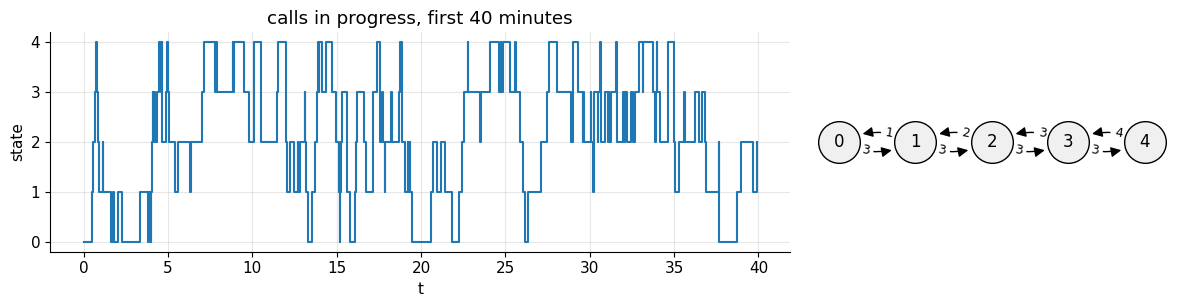

time fractions (sim): [0.058 0.177 0.282 0.278 0.205]
fraction of time all K channels busy (sim): 0.2047   <- CP8 #3 gives the Erlang loss formula: 0.2061
empirical Q:
 [[-3.05  3.05  0.    0.    0.  ]
 [ 0.99 -4.04  3.05  0.    0.  ]
 [ 0.    1.91 -4.89  2.98  0.  ]
 [ 0.    0.    3.02 -5.97  2.95]
 [ 0.    0.    0.    4.   -4.  ]]


In [12]:
# --- Simulate the switch; count lost calls two ways ------------------------------------------
if switch:
    t, x = switch.sample_path(5000, x0=0, rng=rng)
    fig, ax = plt.subplots(1, 2, figsize=(12, 3.2), gridspec_kw={"width_ratios": [2, 1]})
    plot_path(t[t < 40], x[:np.sum(t < 40)], switch.states, ax[0], "calls in progress, first 40 minutes")
    switch.plot_rate_diagram(ax=ax[1], layout="line"); plt.tight_layout(); plt.show()
    occ = switch.occupancy((t, x))
    print("time fractions (sim):", occ.round(3))
    print("fraction of time all K channels busy (sim):", occ[K].round(4), "  <- CP8 #3 gives the Erlang loss formula:", round(erlang_loss(lam/mu, K), 4))
    print("empirical Q:\n", empirical_Q(switch, t, x).round(2))

In [13]:
def switch_exp(K=4, lam=3.0):
    """More channels or fewer calls: how often is the switch full?"""
    ch = CTMC(switch_Q(K, lam, mu))
    t, x = ch.sample_path(3000, x0=0, rng=np.random.default_rng(2))
    occ = ch.occupancy((t, x))
    plt.figure(figsize=(6, 3)); plt.bar(range(K+1), occ, alpha=.6, label="time fraction (sim)")
    plt.plot(range(K+1), ch.stationary(), "ko", label="limiting distribution (Part 3)"); plt.xlabel("calls in progress"); plt.legend()
    plt.title(f"K={K}, lambda={lam}: P(full) = {occ[K]:.3f} (sim), {erlang_loss(lam/mu, K):.3f} (Erlang loss)"); plt.show()

show(switch_exp, K=IntSlider(min=1, max=12, value=4) if HAS_W else 4,
     lam=FloatSlider(min=.5, max=8, step=.5, value=3) if HAS_W else 3.0)

interactive(children=(IntSlider(value=4, description='K', max=12, min=1), FloatSlider(value=3.0, description='…

**Think about it** — (i) Why is the departure rate $i\mu$ and not $\mu$? What is
being minimised? (ii) If the switch instead **queued** rejected calls (infinite
waiting room, $K$ servers), which rows of $Q$ would change? (That is the $M/M/K$
queue of Ch.\,8.)

---
## Problem 4 — A colony of amoebae *(slides pp. 25–26/63)*

> Consider a colony of amoebae whose lifetimes are independent $\exp(\mu)$ random
> variables. During its lifetime, each amoeba produces offsprings (i.e. splits into
> two) in a $PP(\lambda)$ fashion. All amoebae behave independently. As soon as the
> last amoeba in the colony dies, a lab technician introduces a new amoeba after an
> $\exp(\lambda_0)$ time. Let $X(t)$ be the number of amoebae in the colony at time
> $t$. Model $\{X(t),t\ge0\}$ as a CTMC.

### Model
$S=\{0,1,2,\dots\}$ — infinite. With $n\ge1$ amoebae, $n$ death clocks and $n$
splitting clocks run: $n\to n-1$ at rate $n\mu$, $n\to n+1$ at rate $n\lambda$; from 0
the technician's clock gives $0\to1$ at rate $\lambda_0$. In code we **truncate** at
some $N$ (no births from $N$) — always say so, and check that $N$ is rarely reached.

In [14]:
def amoeba_Q(N, lam, mu, lam0):
    """Generator truncated at N amoebae (no birth from state N)."""
    Q = np.zeros((N+1, N+1))
    Q[0, 1] = lam0
    for n in range(1, N+1):
        Q[n, n-1] = n * mu
        if n < N: Q[n, n+1] = n * lam
    np.fill_diagonal(Q, -Q.sum(axis=1))
    return Q

N, lam, mu, lam0 = 30, 0.8, 1.0, 0.5          # per hour; deaths slightly faster than splits -> colony keeps dying out
Q4 = amoeba_Q(N, lam, mu, lam0)
amoebae = build_ctmc(Q4, list(range(N+1)))
print(Q4[:5, :5]); print("rows sum to 0:", np.allclose(Q4.sum(axis=1), 0))

[[-0.5  0.5  0.   0.   0. ]
 [ 1.  -1.8  0.8  0.   0. ]
 [ 0.   2.  -3.6  1.6  0. ]
 [ 0.   0.   3.  -5.4  2.4]
 [ 0.   0.   0.   4.  -7.2]]
rows sum to 0: True


In [15]:
check_rows0(Q4)
check("q[0,1] = lambda_0",  None if np.isnan(Q4[0, 1]) else Q4[0, 1], lam0, tol=1e-9)
check("q[3,4] = 3 lambda",  None if np.isnan(Q4[3, 4]) else Q4[3, 4], 3*lam, tol=1e-9)
check("q[3,2] = 3 mu",      None if np.isnan(Q4[3, 2]) else Q4[3, 2], 3*mu, tol=1e-9)
check("q[3,3] = -3(lambda+mu)", None if np.isnan(Q4[3, 3]) else Q4[3, 3], -3*(lam+mu), tol=1e-9)

[OK ] rows sum to 0, off-diagonal >= 0: got 3.55271e-15   (reference 0)
[OK ] q[0,1] = lambda_0: got 0.5   (reference 0.5)
[OK ] q[3,4] = 3 lambda: got 2.4   (reference 2.4)
[OK ] q[3,2] = 3 mu: got 3   (reference 3)
[OK ] q[3,3] = -3(lambda+mu): got -5.4   (reference -5.4)


True

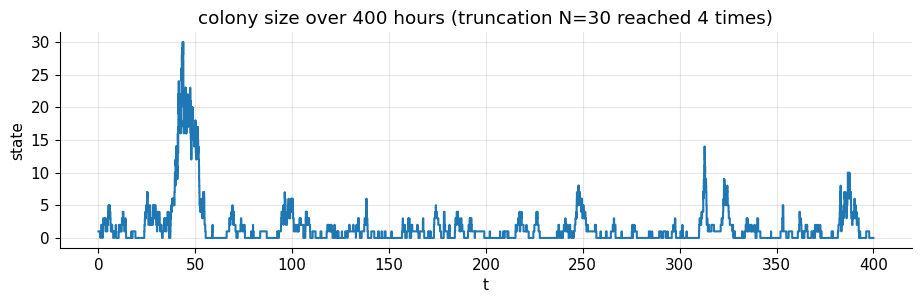

time fractions in states 0..6 (sim): [0.458 0.259 0.111 0.059 0.031 0.023 0.011]
number of extinctions: 95


In [16]:
# --- Simulate the colony: extinctions and restarts --------------------------------------------
if amoebae:
    t, x = amoebae.sample_path(400, x0=1, rng=rng)
    fig, ax = plt.subplots(figsize=(11, 2.8)); plot_path(t, x, None, ax, f"colony size over 400 hours (truncation N={N} reached {int((x == N).sum())} times)")
    plt.show()
    print("time fractions in states 0..6 (sim):", amoebae.occupancy((t, x))[:7].round(3))
    print("number of extinctions:", int(np.sum((x[1:] == 0) & (x[:-1] == 1))))

In [17]:
def amoeba_exp(lam=0.8, mu=1.0):
    """Births faster than deaths: the colony explodes and the truncation bites; births slower: extinctions and restarts."""
    ch = CTMC(amoeba_Q(N, lam, mu, lam0))
    t, x = ch.sample_path(300, x0=1, rng=np.random.default_rng(3))
    fig, ax = plt.subplots(figsize=(9, 2.6)); plot_path(t, x, None, ax, f"lambda={lam}, mu={mu}: fraction of time at the truncation N={N}: {ch.occupancy((t, x))[N]:.3f}"); plt.show()

show(amoeba_exp, lam=FloatSlider(min=.2, max=1.6, step=.1, value=.8) if HAS_W else .8,
     mu=FloatSlider(min=.2, max=1.6, step=.1, value=1.0) if HAS_W else 1.0)

interactive(children=(FloatSlider(value=0.8, description='lam', max=1.6, min=0.2), FloatSlider(value=1.0, desc…

**Think about it** — (i) With $\lambda>\mu$ the process drifts to infinity and no
limiting distribution exists (Part 3: the chain is not positive recurrent) — how
does the truncated model hide that? (ii) The technician makes 0 a non-absorbing
state; without her, what kind of state is 0?

---
## Problem 5 — Two different machines, one repair person (FCFS) *(slides pp. 27–28/63)*

> There are two different machines on a shopfloor with respective up times
> $\exp(\mu_1)$ and $\exp(\mu_2)$. There is a single repair person who is responsible
> for both these machines. The repair times are respectively $\exp(\lambda_1)$ and
> $\exp(\lambda_2)$. The repair person uses a first-come-first-serve (FCFS) policy.
> Model this system as a CTMC.

### Model
"Both down" is not one state: FCFS means the state must record **who is being
repaired**. $S=\{0,1,2,3,4\}$ = {both up; 1 up & 2 down; 1 down & 2 up; both down, 1 in
repair; both down, 2 in repair}. Arcs: $0\to1$ ($\mu_2$), $0\to2$ ($\mu_1$), $1\to0$
($\lambda_2$), $2\to0$ ($\lambda_1$), $1\to4$ ($\mu_1$: machine 1 fails while 2 is being
repaired), $2\to3$ ($\mu_2$), $3\to1$ ($\lambda_1$), $4\to2$ ($\lambda_2$).

In [18]:
mu1, mu2, lam1, lam2 = 1.0, 2.0, 3.0, 4.0      # per day
S5 = ["both up", "1 up, 2 down", "1 down, 2 up", "both down, 1 in repair", "both down, 2 in repair"]
Q5 = np.zeros((5, 5))
Q5[0, 1], Q5[0, 2] = mu2, mu1
Q5[1, 0], Q5[1, 4] = lam2, mu1
Q5[2, 0], Q5[2, 3] = lam1, mu2
Q5[3, 1] = lam1
Q5[4, 2] = lam2
np.fill_diagonal(Q5, -Q5.sum(axis=1))
fcfs = build_ctmc(Q5, S5)
print(Q5); print(fcfs.summary())

[[-3.  2.  1.  0.  0.]
 [ 4. -5.  0.  0.  1.]
 [ 3.  0. -5.  2.  0.]
 [ 0.  3.  0. -3.  0.]
 [ 0.  0.  4.  0. -4.]]
5 states; 1 communicating class(es)
  ['both up', '1 up, 2 down', '1 down, 2 up', 'both down, 1 in repair', 'both down, 2 in repair']: recurrent
absorbing: none
sojourn rates lambda_i: [3.0, 5.0, 5.0, 3.0, 4.0]
irreducible (finite => ergodic, no aperiodicity needed): True


In [19]:
check_rows0(Q5)
for (i, j, v, name) in [(0, 1, mu2, "q[0,1] = mu2"), (1, 4, mu1, "q[1,4] = mu1 (1 fails while 2 is repaired)"),
                        (4, 2, lam2, "q[4,2] = lambda2 (FCFS: 2 finishes first)"), (3, 1, lam1, "q[3,1] = lambda1"),
                        (1, 3, 0.0, "q[1,3] = 0 (cannot jump the queue)")]:
    check(name, None if np.isnan(Q5[i, j]) else Q5[i, j], v, tol=1e-9)

[OK ] rows sum to 0, off-diagonal >= 0: got 0   (reference 0)
[OK ] q[0,1] = mu2: got 2   (reference 2)
[OK ] q[1,4] = mu1 (1 fails while 2 is repaired): got 1   (reference 1)
[OK ] q[4,2] = lambda2 (FCFS: 2 finishes first): got 4   (reference 4)
[OK ] q[3,1] = lambda1: got 3   (reference 3)
[OK ] q[1,3] = 0 (cannot jump the queue): got 0   (reference 0)


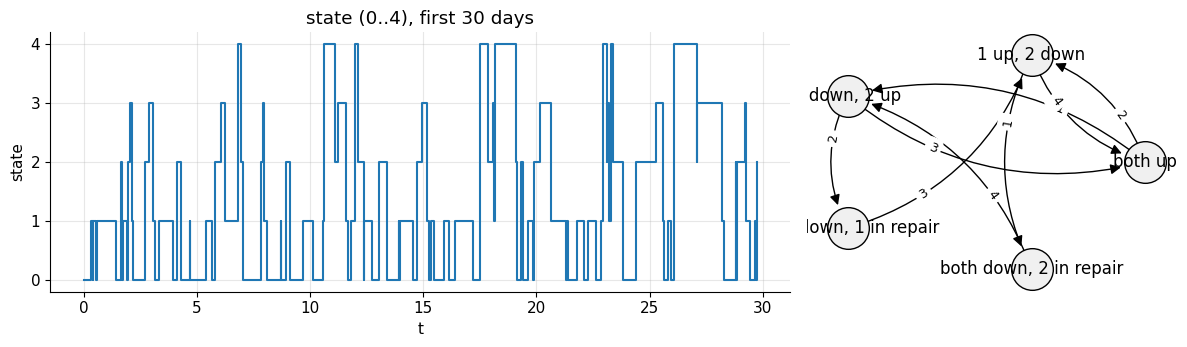

empirical Q (rounded):
 [[-3.07  2.01  1.06  0.    0.  ]
 [ 3.85 -4.98  0.    0.    1.13]
 [ 2.92  0.   -4.87  1.95  0.  ]
 [ 0.    3.26  0.   -3.26  0.  ]
 [ 0.    0.    4.    0.   -4.  ]]
arcs that never occurred (should be the structural zeros): [(0, 3), (0, 4), (1, 2), (1, 3), (2, 1), (2, 4), (3, 0), (3, 2), (3, 4), (4, 0), (4, 1), (4, 3)]
machine 1 up (sim): 0.688   machine 2 up (sim): 0.6   <- CP8 #4 derives these in closed form


In [20]:
# --- Simulate one year; check the arcs from the data; time each machine is up -------------------
if fcfs:
    t, x = fcfs.sample_path(365, x0=0, rng=rng)
    fig, ax = plt.subplots(1, 2, figsize=(12, 3.6), gridspec_kw={"width_ratios": [2, 1]})
    plot_path(t[t < 30], x[:np.sum(t < 30)], [0, 1, 2, 3, 4], ax[0], "state (0..4), first 30 days")
    fcfs.plot_rate_diagram(ax=ax[1], layout="circular"); plt.tight_layout(); plt.show()
    Qh = empirical_Q(fcfs, t, x)
    print("empirical Q (rounded):\n", Qh.round(2))
    print("arcs that never occurred (should be the structural zeros):", [(i, j) for i in range(5) for j in range(5) if i != j and Qh[i, j] == 0])
    occ = fcfs.occupancy((t, x))
    print("machine 1 up (sim):", (occ[0] + occ[1]).round(3), "  machine 2 up (sim):", (occ[0] + occ[2]).round(3), "  <- CP8 #4 derives these in closed form")

**Think about it** — (i) Under a *priority* rule (always repair machine 1 first,
pre-empting machine 2), which states change and which arcs appear? (ii) With
*two* repair persons the states 3 and 4 merge — write the 4-state generator and
compare with `machine_repair`-style reasoning (the machines are now independent).

---
## Wrap-up — five generators, one recipe

| system | state $X(t)$ | $S$ | key modeling step |
|---|---|---|---|
| one machine | up/down | $\{0,1\}$ | one clock per direction |
| two photocopy machines, 2 crews | # up | $\{0,1,2\}$ | $k$ clocks running $\Rightarrow$ rate $k\times$ |
| switch with $K$ channels | # calls | $\{0,\dots,K\}$ | birth & death, $\mu_i=i\mu$ |
| amoebae | # alive | $\{0,1,\dots\}$ | infinite $S$; truncate honestly |
| two machines, FCFS repair | who is up / who is in repair | 5 states | the state must carry the queue order |

Every entry of $Q$ is the rate of one exponential clock; no self-loops; rows sum to 0.
**Next (CP8):** what $Q$ buys us — $P(t)=e^{Qt}$, the limiting distribution
$\boldsymbol pQ=0$, and long-run costs.